## 1. Importamos las librerías para el EDA


In [140]:
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Carga y exploración de la tabla principal: fact_viajes

In [141]:
# 1. Cargar el dataset desde la carpeta data
df_viajes = pd.read_csv('data/fact_viajes.csv')

# 2. Ver columnas y tipos de datos
print("--- Columnas y Tipos de Datos ---")
display(df_viajes.dtypes)

# 3. Primeras 5 filas
print("--- Primeras 5 filas (head) ---")
display(df_viajes.head())

# 4. Ultimas 5 filas
print("--- Ultimas 5 filas (tail) ---")
display(df_viajes.tail())

# 5. 5 filas aleatorias
print("--- 5 filas aleatorias (sample) ---")
display(df_viajes.sample(5))

--- Columnas y Tipos de Datos ---


viaje_id                    int64
linea_id                    int64
vehiculo_id                 int64
conductor_id                int64
parada_origen_id            int64
parada_destino_id           int64
fecha                         str
anno                        int64
mes                         int64
dia_semana                    str
es_festivo                   bool
franja_horaria                str
hora_salida_prog              str
hora_salida_real              str
hora_llegada_real             str
retraso_salida_min          int64
duracion_real_min           int64
pasajeros_subidos         float64
ocupacion_pct             float64
km_programados            float64
km_recorridos             float64
viaje_completado             bool
consumo                   float64
tarifa_predominante_id      int64
dtype: object

--- Primeras 5 filas (head) ---


,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,...,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
0,1,4,2,2,17,116,2023-08-14,2023,8,Monday,...,19:22,19,73,78.0,0.609,14.1,14.1,True,4.69,4
1,2,4,3,3,5,48,2024-05-20,2024,5,Monday,...,08:30,13,67,115.0,0.885,14.1,14.1,True,5.86,2
2,3,5,4,4,33,110,2023-08-15,2023,8,Tuesday,...,13:05,0,35,47.0,0.362,7.3,7.3,True,3.15,3
3,4,2,5,5,37,116,2022-03-23,2022,3,Wednesday,...,21:36,0,46,111.0,0.888,11.2,11.2,True,3.50,9
4,5,5,6,6,12,115,2022-03-24,2022,3,Thursday,...,18:50,8,32,75.0,0.405,7.3,7.3,True,3.13,3


--- Ultimas 5 filas (tail) ---


,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,...,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
49995,49996,1,17,17,38,93,2024-09-23,2024,9,Monday,...,17:25,0,95,57.0,0.445,18.4,18.4,True,7.02,3
49996,49997,7,18,18,34,55,2023-06-28,2023,6,Wednesday,...,16:58,1,47,10.0,0.077,8.9,8.9,True,3.05,2
49997,49998,5,19,19,31,43,2023-02-05,2023,2,Sunday,...,06:51,3,28,98.0,0.754,7.3,7.3,True,2.23,2
49998,49999,1,20,20,12,114,2022-04-05,2022,4,Tuesday,...,22:23,2,91,118.0,0.944,18.4,18.4,True,7.11,3
49999,50000,9,21,21,1,77,2023-04-20,2023,4,Thursday,...,10:59,0,79,85.0,0.459,19.8,19.8,True,7.57,2


--- 5 filas aleatorias (sample) ---


,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,...,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
5167,5168,9,3,17,37,91,2022-06-10,2022,6,Friday,...,16:31,2,69,16.0,0.123,19.8,19.8,True,7.15,3
29427,29428,10,29,1,18,56,2024-02-19,2024,2,Monday,...,00:41,1,80,62.0,0.496,15.0,15.0,True,17.99,2
8710,8711,4,18,4,18,41,2023-07-01,2023,7,Saturday,...,23:31,3,58,12.0,0.092,14.1,14.1,True,4.64,2
23662,23663,5,18,4,5,79,2024-07-30,2024,7,Tuesday,...,21:14,5,39,110.0,0.846,7.3,7.3,True,3.18,4
42139,42140,6,15,1,6,51,2024-12-20,2024,12,Friday,...,11:44,1,83,7.0,0.055,23.5,23.5,True,9.91,3


## 3. Análisis de valores nulos

In [142]:
# 1. Calculamos el total de nulos por columna
total_nulos = df_viajes.isnull().sum()

# 2. Caculamos el porcentaje de nulos por columna
porcentaje_nulos = (total_nulos / len(df_viajes)) * 100

# 3. Combinamos ambos resultados en un DataFrame
tabla_nulos = pd.DataFrame({
    'Total Nulos': total_nulos,
    'Porcentaje (%)': porcentaje_nulos
})

# 4. Filtramos para ver solo las columnas que tienen más de 0 nulos y ordenamos de mayor a menor
tabla_nulos_filtrada = tabla_nulos[tabla_nulos['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False)

print("--- Resumen de Valores Nulos en fact_viajes ---")
if tabla_nulos_filtrada.empty:
    print("No hay valores nulos en esta tabla")
else:
    display(tabla_nulos_filtrada)



--- Resumen de Valores Nulos en fact_viajes ---


,Total Nulos,Porcentaje (%)
consumo,1065,2.13
pasajeros_subidos,40,0.08


#### Las dos columnas que tienen valosres nulos son 'consumo' y 'pasajeros'

### 3.1 Analizamos los valores nulos de manera más exhaustiva


In [143]:
# 1. Filtramos los viajes que no tienen registrado el consumo
nulos_consumo = df_viajes[df_viajes['consumo'].isnull()]

print("--- Top 5 Vehículos con fallos en el registro de 'consumo' ---")
# Contamos cuántos nulos tiene cada vehículo
display(nulos_consumo['vehiculo_id'].value_counts().head())
print("\n" + "="*60 + "\n")

# 2. Filtramos los viajes que no tienen registrado los pasajeros
nulos_pasajeros = df_viajes[df_viajes['pasajeros_subidos'].isnull()]

print("--- Top 5 Líneas con fallos en el registro de 'pasajeros' ---")
display(nulos_pasajeros['linea_id'].value_counts().head())
print("\n" + "="*60 + "\n")

# 3. Filtramos tambien por los vehiculos
print("\n--- Top 5 Vehículos con fallos en el registro de 'pasajeros' ---")
display(nulos_pasajeros['vehiculo_id'].value_counts().head())


--- Top 5 Vehículos con fallos en el registro de 'consumo' ---


vehiculo_id
23    110
39    107
9     105
37    102
7     102
Name: count, dtype: int64



--- Top 5 Líneas con fallos en el registro de 'pasajeros' ---


linea_id
5    7
9    7
6    5
8    4
1    4
Name: count, dtype: int64




--- Top 5 Vehículos con fallos en el registro de 'pasajeros' ---


vehiculo_id
20    3
26    3
9     2
5     2
23    2
Name: count, dtype: int64

#### En esta muestra encontramos que 2 de cada 5 vehiculos coinciden en nulos con las lineas

## 3.2 Estudiamos la interseción entre ambas columnas

In [144]:
col_consumo = 'consumo'
col_pasajeros = 'pasajeros_subidos'

# 1. Obtenemos la lista de todos los vehiculos que han fallado
vehiculos_consumo = set(df_viajes[df_viajes[col_consumo].isnull()]['vehiculo_id'].unique())
vehiculos_pasajeros = set(df_viajes[df_viajes[col_pasajeros].isnull()]['vehiculo_id'].unique())

# 2. Calculamos cuántos coinciden exactamente usando la intersección de conjuntos
interseccion_vehiculos = vehiculos_consumo.intersection(vehiculos_pasajeros)

# 3. Comprobamos cuantos fallan a la vez
interseccion_fallos = df_viajes[df_viajes[col_consumo].isnull() & df_viajes[col_pasajeros].isnull()]

print("--- RADIOGRAFÍA TOTAL DE FALLOS ---")
print(f"Total buses distintos con fallos de consumo: {len(vehiculos_consumo)}")
print(f"Total buses distintos con fallos de pasajeros: {len(vehiculos_pasajeros)}")
print(f"Buses que tienen AMBOS fallos: {len(interseccion_vehiculos)}")
print("-" * 35)
print(f"Total de VIAJES con fallo en consumo: {df_viajes[col_consumo].isnull().sum()}")
print(f"Total de VIAJES con fallo en pasajeros: {df_viajes[col_pasajeros].isnull().sum()}")
print(f"Viajes concretos donde fallaron AMBAS cosas a la vez: {len(interseccion_fallos)}")

--- RADIOGRAFÍA TOTAL DE FALLOS ---
Total buses distintos con fallos de consumo: 11
Total buses distintos con fallos de pasajeros: 26
Buses que tienen AMBOS fallos: 7
-----------------------------------
Total de VIAJES con fallo en consumo: 1065
Total de VIAJES con fallo en pasajeros: 40
Viajes concretos donde fallaron AMBAS cosas a la vez: 1


#### Se concluye que no existe relación técnica entre ambos fallos

## 3.3 Tratamiento de valores nulos

#### Para el tratamiento de los nulos de este dataset vamos a realizar la eliminación de todas las filas de la columna 'pasajeros' debido a que supone solo el 0.08 % del resultado total. En cambio, para la columna consumo haremos una media para rellenar esos valores nulos debido a que el porcentaje de los mismos asciente al 2.13%.

In [145]:
print(f"Filas antes de la limpieza: {len(df_viajes)}")

# 1. Borramos SOLO las filas donde 'pasajeros' es nulo
df_viajes = df_viajes.dropna(subset=['pasajeros_subidos'])
print(f"Filas después de la limpieza: {len(df_viajes)}")    

# 2. Calculamos el consumo mediano de toda la flota
consumo_mediana = df_viajes['consumo'].median()
print(f"Consumo mediano de la flota: {consumo_mediana}")

# 3. Rellenamos los nulos de 'consumo' con esa mediana
df_viajes ['consumo'] = df_viajes['consumo'].fillna(consumo_mediana)

print(f"Filas después de la limpieza: {len(df_viajes)}")
print("\n--- Comprobación final de nulos ---")
display(df_viajes[['consumo', 'pasajeros_subidos']].isnull().sum())


Filas antes de la limpieza: 50000
Filas después de la limpieza: 49960
Consumo mediano de la flota: 5.34
Filas después de la limpieza: 49960

--- Comprobación final de nulos ---


consumo              0
pasajeros_subidos    0
dtype: int64

## 4. Tratamiento de datos


In [146]:
# --- 1. TRATAMIENTO DE FECHAS Y HORAS ---

# 1.1. La columna 'fecha' la dejamos estricta porque sabemos que es Año-Mes-Día
df_viajes['fecha'] = pd.to_datetime(df_viajes['fecha'], format='%Y-%m-%d', errors='coerce')

# 1.2. Agrupamos solo las columnas con horas y les aplicamos el formato mixto
columnas_horas = [
    'hora_salida_prog', 
    'hora_salida_real', 
    'hora_llegada_real'
]

for col in columnas_horas:
    df_viajes[col] = pd.to_datetime(df_viajes[col], format='mixed', errors='coerce').dt.time


# --- 2. TRATAMIENTO DE MESES ---

traductor_meses = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}

df_viajes['mes'] = df_viajes['mes'].map(traductor_meses)


# --- 3. COMPROBACIÓN FINAL ---

print("--- Comprobación de nulos en horas ---")
display(df_viajes[['hora_salida_prog', 'hora_salida_real', 'hora_llegada_real']].isnull().sum())

print("\n--- Muestra de los meses actualizados ---")
display(df_viajes[['fecha', 'hora_salida_prog', 'mes']].sample(5))

--- Comprobación de nulos en horas ---


hora_salida_prog     0
hora_salida_real     0
hora_llegada_real    0
dtype: int64


--- Muestra de los meses actualizados ---


,fecha,hora_salida_prog,mes
16831,2024-02-26,06:50:00,February
38670,2022-12-04,18:30:00,December
12244,2024-07-26,09:20:00,July
27794,2024-05-26,10:40:00,May
17624,2023-04-17,10:10:00,April


## 5 Estudio de outliers

### 5.1 Visualización de posibles columnas con outliers

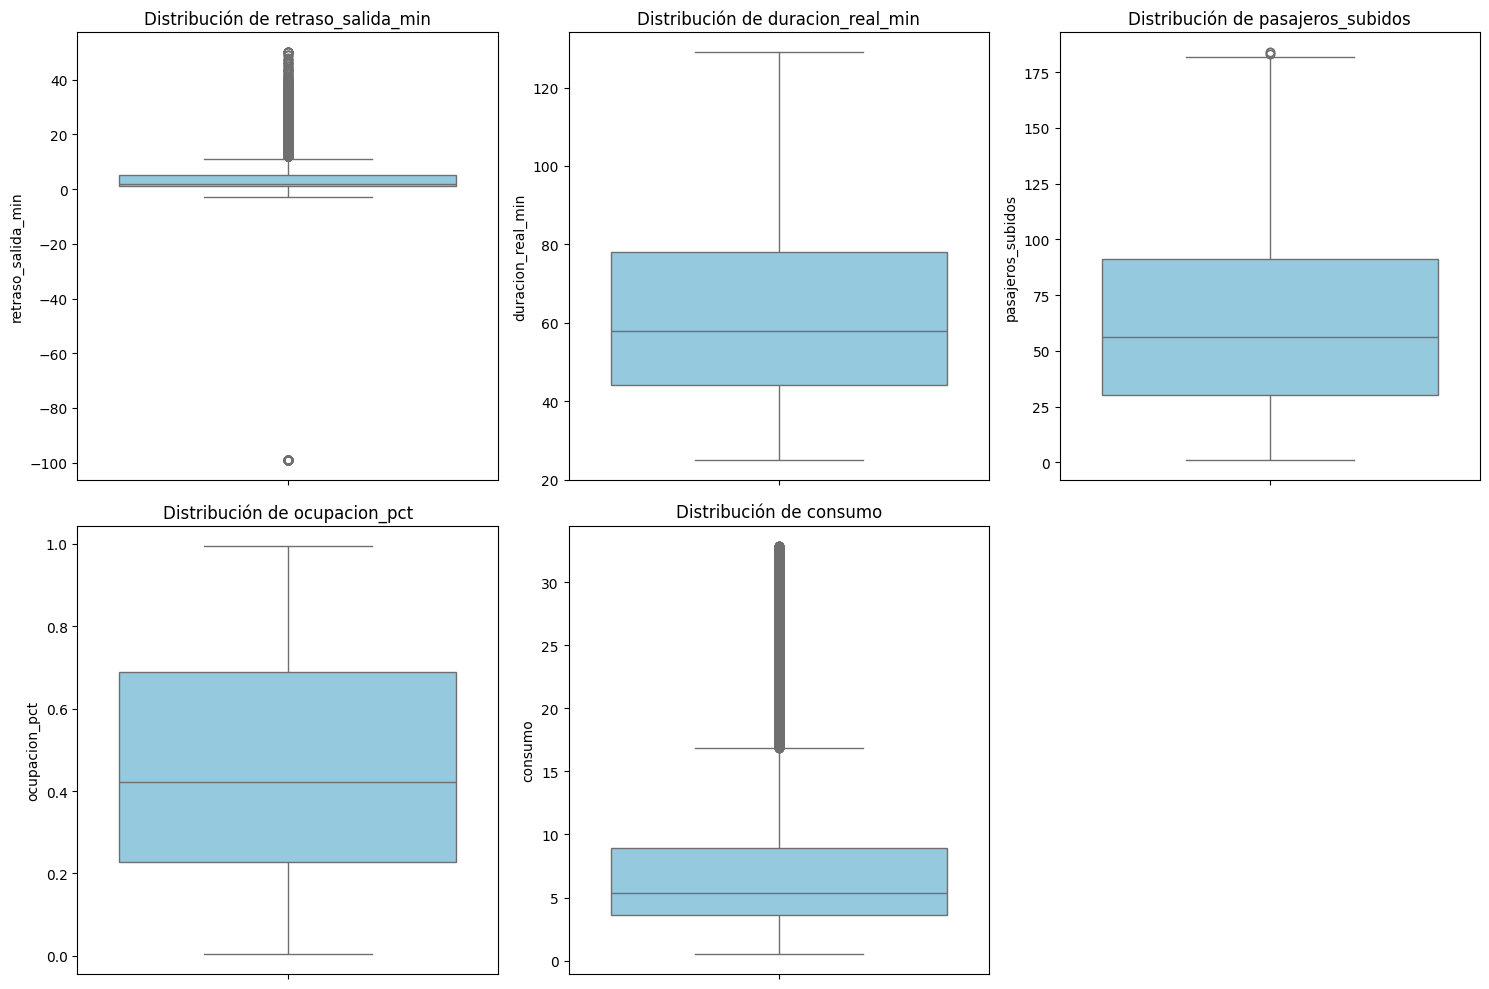


--- Resumen Estadístico de las variables clave ---


,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,consumo
count,49960.000000,49960.000000,49960.000000,49960.000000,49960.000000
mean,3.891253,62.598299,61.283907,0.455313,7.644995
std,6.763067,23.846471,36.847517,0.264234,6.164504
min,-99.000000,25.000000,1.000000,0.005000,0.550000
25%,1.000000,44.000000,30.000000,0.227000,3.630000
50%,2.000000,58.000000,56.000000,0.422000,5.340000
75%,5.000000,78.000000,91.000000,0.688000,8.930000
max,50.000000,129.000000,184.000000,0.995000,32.860000


In [147]:
# 1. Seleccionamos las columnas de interés para la visualización
columnas_outliers = [
    'retraso_salida_min', 
    'duracion_real_min', 
    'pasajeros_subidos', 
    'ocupacion_pct', 
    'consumo'
]

# 2. Configuración visual
plt.figure(figsize=(15, 10))

# El bucle recorre nuestras columnas y pinta un Boxplot (gráfico de caja) para cada una
for i, col in enumerate(columnas_outliers, 1):
    plt.subplot(2, 3, i) # Crea una cuadrícula de 2 filas por 3 columnas
    sns.boxplot(y=df_viajes[col], color='skyblue')
    plt.title(f'Distribución de {col}')

plt.tight_layout() # Ajusta los márgenes automáticamente para que no se pisen
plt.show()

# 3. Resumen estadístico de las variables clave
print("\n--- Resumen Estadístico de las variables clave ---")
display(df_viajes[columnas_outliers].describe())

### 5.2 Tratamiento de Outliers (Limpieza y Winsorización)

In [148]:
# --- 1. ELIMINACIÓN DEL ERROR FÍSICO (Retraso negativo extremo) ---

# Eliminamos de la tabla el viaje ilógico quedándonos con los mayores a -50
df_viajes = df_viajes[df_viajes['retraso_salida_min'] >= -50]
print(f"Filas tras borrar el error de salida anticipada: {len(df_viajes)}")


# --- 2. INVESTIGACIÓN DE ANOMALÍAS DE CONSUMO ---

# Calculamos la matemática del IQR para saber dónde está la frontera
Q1 = df_viajes['consumo'].quantile(0.25)
Q3 = df_viajes['consumo'].quantile(0.75)
IQR = Q3 - Q1
limite_superior_consumo = Q3 + 1.5 * IQR

print(f"\nFrontera máxima calculada para un consumo normal: {limite_superior_consumo:.2f}")

# Aislamos los viajes sospechosos en una tabla temporal
viajes_excesivos = df_viajes[df_viajes['consumo'] > limite_superior_consumo]

print(f"\nSe han detectado {len(viajes_excesivos)} viajes superando el límite.")

# --- 3. Buscamos un posible patrón en los vehículos ---

print("\n--- Top 5 Vehículos con más excesos de consumo ---")
# Contamos cuántas veces aparece cada vehículo en esta lista negra
vehiculos_infractores = viajes_excesivos['vehiculo_id'].value_counts().head(5)
display(vehiculos_infractores)

Filas tras borrar el error de salida anticipada: 49880

Frontera máxima calculada para un consumo normal: 16.88

Se han detectado 5109 viajes superando el límite.

--- Top 5 Vehículos con más excesos de consumo ---


vehiculo_id
8     505
38    483
37    476
29    471
22    471
Name: count, dtype: int64

## 6. Visualizaciones de la tabla 'fact_viajes'

/var/folders/g1/r2_bvb_16ns9g5jwyjs6mj300000gn/T/ipykernel_87712/469902803.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


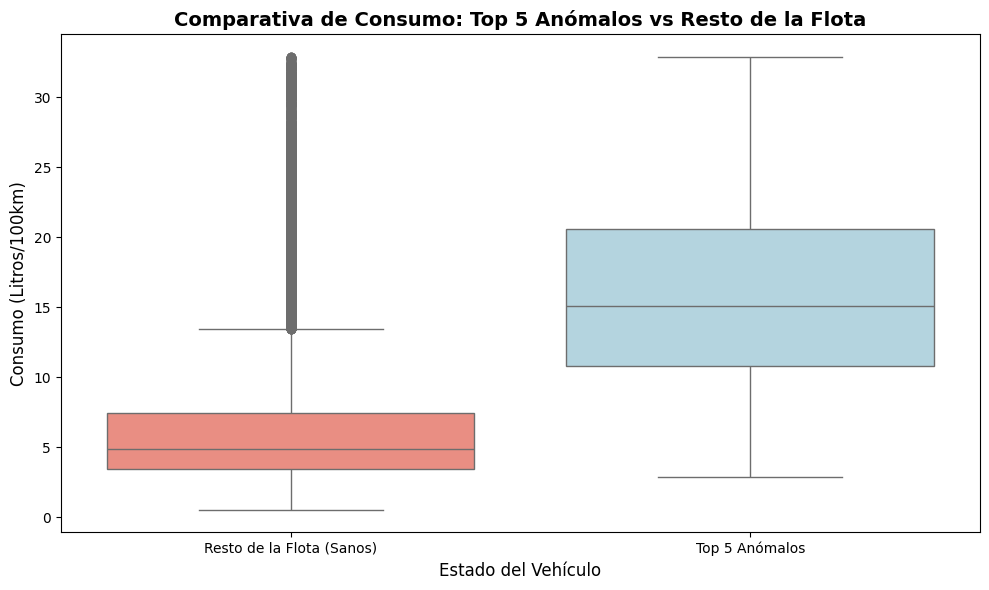


--- Consumo Medio por Grupo ---


estado_vehiculo
Resto de la Flota (Sanos)     6.53
Top 5 Anómalos               15.91
Name: consumo, dtype: float64

In [149]:

# --- 1. CLASIFICACIÓN DE LA FLOTA ---

# Listamos con los IDs de los 5 vehículos problemáticos que descubrimos
vehiculos_infractores = [8, 38, 37, 29, 22]

# Creamos una columna nueva (flag) para etiquetar a cada viaje
df_viajes['estado_vehiculo'] = np.where(
    df_viajes['vehiculo_id'].isin(vehiculos_infractores), 
    'Top 5 Anómalos', 
    'Resto de la Flota (Sanos)'
)

# --- 2. CREACIÓN DEL GRÁFICO VISUAL ---

plt.figure(figsize=(10, 6))

# Usamos Seaborn para pintar el gráfico, separando por el grupo que acabamos de crear
sns.boxplot(
    data=df_viajes, 
    x='estado_vehiculo', 
    y='consumo', 
    palette=['salmon', 'lightblue']
)

# Añadimos títulos
plt.title('Comparativa de Consumo: Top 5 Anómalos vs Resto de la Flota', fontsize=14, fontweight='bold')
plt.xlabel('Estado del Vehículo', fontsize=12)
plt.ylabel('Consumo (Litros/100km)', fontsize=12)

plt.tight_layout()
plt.show()


# --- 3. EL DATO DE RESPALDO ---

print("\n--- Consumo Medio por Grupo ---")
# Agrupamos por nuestra nueva categoría y sacamos la media de consumo
resumen_medias = df_viajes.groupby('estado_vehiculo')['consumo'].mean().round(2)
display(resumen_medias)

## Conclusiones de la Exploración de Datos: `fact_viajes.csv`

### 1. Resumen de Estructura y Dimensiones
La tabla de hechos principal `fact_viajes` constituye el núcleo operativo del proyecto, registrando el historial analítico de las expediciones de la red.
* **Volumen Inicial:** ~50.000 registros analizados.
* **Estructura Temporal:** Cobertura de datos históricos entre 2022 y 2024.
* **Estado de Tipos de Datos:** Se ha estandarizado la columna `fecha` al tipo optimizado `datetime64[ns]`. Se tomó la decisión técnica de mantener el formato nativo de marcas de tiempo de Pandas (preservando las horas nominales `00:00:00` subyacentes) para garantizar la máxima escalabilidad y rendimiento en futuras operaciones de combinación (JOINs) y segmentación temporal en el modelo relacional.

### 2. Registro de Decisiones de Limpieza (Data Quality Log)
Durante el proceso de auditoría y saneamiento de la calidad de los datos, se identificaron y resolvieron anomalías críticas mediante lógica de negocio aplicada:

| Dimensión/Campo | Tipo de Problema | Frecuencia (Filas) | Decisión Tomada | Justificación Técnica / Negocio |
| :--- | :--- | :--- | :--- | :--- |
| `retraso_salida_min` | Outlier Extremo / Error Físico Imposible | 80 filas (~0.16% del dataset) | **Eliminación (Drop):** Exclusión de registros con retrasos menores a -50 min (ej. anomalía severa de -100 min). | Operativamente absurdo. Un autobús de línea regular no inicia su ruta con más de una hora y media de anticipación respecto al horario programado. Apunta a fallos de sincronización de relojes o GPS. |
| `consumo` | Outliers Masivos por Límite Superior | 5.109 filas (~10.2% del dataset) | **Conservación Intacta:** Cancelación del proceso estándar de Winsorización (`.clip()`). | Tras una investigación forense distributiva, se determinó que los valores extremos no corresponden a ruido estadístico o errores de tecleo, sino a una señal real de ineficiencia operativa. |

*El volumen neto de la tabla tras la limpieza quirúrgica es de **49.880 filas**, manteniendo una integridad muestral óptima.*

### 3. Análisis Forense de Outliers e Insights de Negocio

El análisis de atípicos mediante el método estadístico del **Rango Intercuartílico (IQR)** arrojó una frontera de consumo normal establecida en **16.88 Litros/100km**. El comportamiento de los viajes que superaban este límite desveló un patrón estructural crítico para la gestión de activos de MetroBus:

* **Concentración de Anomalías:** De los 5.109 viajes con consumo excesivo, un total de **2.406 viajes (aproximadamente el 47%)** fueron provocados de forma exclusiva por un grupo reducido de **5 vehículos** específicos: `vehiculo_id` **8, 38, 37, 29 y 22**.
* **Impacto Visual y Estadístico:** La evaluación comparativa mediante diagramas de caja (*Boxplots*) confirma que la mediana de consumo de este "Top 5 Anómalos" se sitúa cerca de los 15 Litros/100km, triplicando el consumo base del resto de la flota eficiente (cuyo centro se ubica en torno a los 5 Litros/100km).

### 4. Hipótesis Generadas para las Siguientes Fases
Los hallazgos de esta fase exploratoria abren líneas de investigación prioritarias para la dirección general, las cuales serán validadas formalmente al cruzar este dataset con las tablas de dimensiones en las fases de SQL y Business Intelligence:

1. **Hipótesis de Obsolescencia o Avería Mecánica:** Los vehículos `8, 38, 37, 29 y 22` representan o bien modelos antiguos con un desgaste mecánico severo (ej. problemas en sistemas de inyección) o pertenecen a una remesa diésel pesada obsoleta. Identificar estos atributos en `dim_vehiculo` permitirá justificar cuantitativamente su sustitución inmediata por unidades híbridas o eléctricas.
2. **Hipótesis de Ineficiencia de Ruta o Desempeño:** El ~53% restante de los excesos de consumo distribuidos uniformemente por la flota podría estar asociado a variables exógenas como perfiles topográficos desfavorables (líneas que superan pendientes pronunciadas) o franjas horarias con congestión de tráfico severo que elevan el tiempo de ralentí del motor.

## 1. Cargay exploracion de la tabla principal: `fact_incidencias`

In [150]:
# 1. Cargamos el dataset
df_incidencias = pd.read_csv('data/fact_incidencias.csv')

# 2. Ver columnas y tipos de datos
print("--- Columnas y Tipos de Datos ---")
display(df_incidencias.dtypes)

# 3. Primeras 5 filas
print("--- Primeras 5 filas (head) ---")
display(df_incidencias.head())

# 4. Ultimas 5 filas
print("--- Ultimas 5 filas (tail) ---")
display(df_incidencias.tail())  

# 5. 5 filas aleatorias
print("--- 5 filas aleatorias (sample) ---")
display(df_incidencias.sample(5))

--- Columnas y Tipos de Datos ---


incidencia_id                int64
viaje_id                     int64
vehiculo_id                  int64
conductor_id                 int64
linea_id                     int64
fecha                          str
anno                         int64
mes                          int64
hora_incidencia                str
tipo_incidencia                str
categoria                      str
severidad                      str
requiere_retirada             bool
duracion_resolucion_min      int64
vehiculo_sustituto            bool
coste_estimado_eur         float64
dtype: object

--- Primeras 5 filas (head) ---


,incidencia_id,viaje_id,vehiculo_id,conductor_id,linea_id,fecha,anno,mes,hora_incidencia,tipo_incidencia,categoria,severidad,requiere_retirada,duracion_resolucion_min,vehiculo_sustituto,coste_estimado_eur
0,1,33554,39,11,4,2022-06-01,2022,6,19:11,Huelga parcial,Operacional,Alta,True,60,False,0.00
1,2,9428,21,21,6,2023-02-16,2023,2,20:42,Fallo electrico,Vehiculo,Alta,True,62,False,575.51
2,3,200,33,5,8,2022-01-20,2022,1,06:21,Accidente leve,Seguridad,Alta,True,29,True,3318.00
3,4,12448,17,17,10,2023-01-16,2023,1,02:30,Vandalismo,Seguridad,Media,False,16,False,651.99
4,5,39490,11,11,6,2023-01-08,2023,1,14:51,Retencion trafico,Externo,Baja,False,14,False,49.88


--- Ultimas 5 filas (tail) ---


,incidencia_id,viaje_id,vehiculo_id,conductor_id,linea_id,fecha,anno,mes,hora_incidencia,tipo_incidencia,categoria,severidad,requiere_retirada,duracion_resolucion_min,vehiculo_sustituto,coste_estimado_eur
3995,3996,46736,33,5,3,2023-04-23,2023,4,14:32,Accidente grave,Seguridad,Critica,True,5,True,9816.47
3996,3997,28682,39,11,2,2024-09-27,2024,9,18:47,Retencion trafico,Externo,Baja,False,21,False,24.14
3997,3998,46607,30,16,2,2023-03-06,2023,3,14:41,Pasajero enfermo,Servicio,Media,False,41,False,52.05
3998,3999,7500,25,25,3,2023-02-17,2023,2,13:50,Pinchazo,Vehiculo,Media,True,11,True,238.32
3999,4000,24976,29,1,8,2022-04-14,2022,4,10:43,Vandalismo,Seguridad,Media,False,5,False,186.83


--- 5 filas aleatorias (sample) ---


,incidencia_id,viaje_id,vehiculo_id,conductor_id,linea_id,fecha,anno,mes,hora_incidencia,tipo_incidencia,categoria,severidad,requiere_retirada,duracion_resolucion_min,vehiculo_sustituto,coste_estimado_eur
2261,2262,36274,29,15,9,2023-10-01,2023,10,18:51,Vandalismo,Seguridad,Media,False,5,False,479.66
3902,3903,10172,9,9,5,2022-02-11,2022,2,20:04,Condiciones meteo,Externo,Media,False,20,False,0.00
3753,3754,46128,13,13,3,2024-08-26,2024,8,21:10,Accidente grave,Seguridad,Critica,True,21,True,9889.34
356,357,34166,21,7,6,2022-12-26,2022,12,21:40,Vandalismo,Seguridad,Media,False,10,False,418.04
2728,2729,5224,17,17,7,2023-03-13,2023,3,22:30,Fallo electrico,Vehiculo,Alta,True,5,True,1910.12


## 2. Análisis de valores nulos

In [151]:
# 1. Calculamos el total de nulos por columna
total_nulos = df_incidencias.isnull().sum()

# 2. Caculamos el porcentaje de nulos por columna
pocentaje_nulos = (total_nulos / len(df_incidencias)) * 100

# 3. Combinamos ambos resultados en un DataFrame
tabla_nulos = pd.DataFrame({
    'Total Nulos': total_nulos,
    'Porcentaje (%)': pocentaje_nulos
})

# 4. Filtramos para ver solo las columnas que tienen más de 0 nulos y ordenamos de mayor a menor
tabla_nulos_filtrada = tabla_nulos[tabla_nulos['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False)

print("--- Resumen de Valores Nulos en fact_incidencias ---")
if tabla_nulos_filtrada.empty:
    print("No hay valores nulos en esta tabla")
else:
    display(tabla_nulos_filtrada)

--- Resumen de Valores Nulos en fact_incidencias ---
No hay valores nulos en esta tabla


## 3. Tratamiento de datos

In [152]:
# --- 1. TRATAMIENTO DE FECHAS Y HORAS ---

# 1.1. La columna 'fecha' la dejamos estricta porque sabemos que es Año-Mes-Día
df_viajes['fecha'] = pd.to_datetime(df_viajes['fecha'], format='%Y-%m-%d', errors='coerce')

# --- 2. TRATAMIENTO DE MESES ---

traductor_meses = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}

df_incidencias['mes'] = df_incidencias['mes'].map(traductor_meses)

# --- 3. COMPROBACIÓN FINAL ---

print("\n--- Muestra de los meses actualizados ---")
display(df_incidencias[['fecha', 'mes']].sample(5))


--- Muestra de los meses actualizados ---


,fecha,mes
1027,2022-07-21,July
3381,2024-09-12,September
3786,2024-12-28,December
962,2024-02-13,February
2234,2023-01-27,January
